# Анализ эффективности товаров Amazon


## Описание проекта


В рамках проекта проводится анализ данных о товарах Amazon с целью изучения того, как такие характеристики, как категория товара, цена, размер скидки, рейтинг и количество оценок, связаны с популярностью товаров и удовлетворённостью покупателей.

Проект выполняется с позиции продуктового аналитика: основная задача заключается не только в описании данных, но и в поиске закономерностей, выявлении различных групп товаров и определении продуктов, которые потенциально требуют дополнительного внимания со стороны бизнеса.


## Бизнес-цель


Цель проекта — оценить эффективность товаров, представленных на Amazon, и определить закономерности, связанные с популярностью товаров и уровнем удовлетворённости покупателей.

Результаты анализа должны помочь понять, какие категории и характеристики товаров связаны с более высокими или низкими показателями, выявить потенциально проблемные товары и сформировать рекомендации для дальнейшего исследования ассортимента и принятия продуктовых решений.


## Аналитические вопросы


1. **Как распределены товары между основными категориями и какие категории представлены в ассортименте наиболее широко?**

2. **Какие категории товаров характеризуются наиболее высоким уровнем пользовательской удовлетворённости на основе рейтинга?**

3. **Какие категории и товары можно считать наиболее популярными на основе количества пользовательских оценок (`rating_count`)?**

4. **Существует ли связь между размером скидки и популярностью товара?**

5. **Существует ли связь между ценой товара и его рейтингом или популярностью?**

6. **Можно ли выделить отдельные сегменты товаров на основе сочетания пользовательской удовлетворённости и популярности?**

7. **Какие товары можно определить как потенциально проблемные: имеющие относительно высокую популярность, но при этом более низкий пользовательский рейтинг?**


# 1. Исходные данные и первичный аудит


## 1.1 Загрузка и общий обзор данных


In [180]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
data=pd.read_csv('amazon.csv')
data.head()

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹399,"₹1,099",64%,4.2,"24,269",High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,₹199,₹349,43%,4.0,"43,994","Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,₹199,"₹1,899",90%,3.9,"7,928",【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,₹329,₹699,53%,4.2,"94,363",The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,₹154,₹399,61%,4.2,"16,905",[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...","As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...


In [181]:
data.shape

(1465, 16)

In [182]:
data.columns

Index(['product_id', 'product_name', 'category', 'discounted_price',
       'actual_price', 'discount_percentage', 'rating', 'rating_count',
       'about_product', 'user_id', 'user_name', 'review_id', 'review_title',
       'review_content', 'img_link', 'product_link'],
      dtype='object')

In [183]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   product_id           1465 non-null   object
 1   product_name         1465 non-null   object
 2   category             1465 non-null   object
 3   discounted_price     1465 non-null   object
 4   actual_price         1465 non-null   object
 5   discount_percentage  1465 non-null   object
 6   rating               1465 non-null   object
 7   rating_count         1463 non-null   object
 8   about_product        1465 non-null   object
 9   user_id              1465 non-null   object
 10  user_name            1465 non-null   object
 11  review_id            1465 non-null   object
 12  review_title         1465 non-null   object
 13  review_content       1465 non-null   object
 14  img_link             1465 non-null   object
 15  product_link         1465 non-null   object
dtypes: obj

## 1.2 Уникальность товаров


In [184]:
data['product_id'].nunique()

1351

In [185]:
len(data['product_id'].value_counts()[data['product_id'].value_counts() > 1])

92

### Вывод по разделу


Датасет содержит 1 465 строк и 16 признаков. В данных представлено 1 351 уникальное значение `product_id`, при этом 92 товара встречаются более одного раза. Все признаки изначально загружены как `object`, а в `rating_count` присутствуют 2 пропущенных значения — эти особенности необходимо учесть при подготовке данных.


# 2. Подготовка и очистка данных


## 2.1 Пропущенные значения и типы данных


In [186]:
data.isna().sum()[data.isna().sum() > 0]

,0
rating_count,2


In [187]:
data.loc[:, 'discounted_price':'rating_count'].head()

,discounted_price,actual_price,discount_percentage,rating,rating_count
0,₹399,"₹1,099",64%,4.2,"24,269"
1,₹199,₹349,43%,4.0,"43,994"
2,₹199,"₹1,899",90%,3.9,"7,928"
3,₹329,₹699,53%,4.2,"94,363"
4,₹154,₹399,61%,4.2,"16,905"


In [188]:
data['rating'].unique()

array(['4.2', '4.0', '3.9', '4.1', '4.3', '4.4', '4.5', '3.7', '3.3',
       '3.6', '3.4', '3.8', '3.5', '4.6', '3.2', '5.0', '4.7', '3.0',
       '2.8', '4', '3.1', '4.8', '2.3', '|', '2', '3', '2.6', '2.9'],
      dtype=object)

In [189]:
data[data['rating'] == '|']

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
1279,B08L12N5H1,Eureka Forbes car Vac 100 Watts Powerful Sucti...,"Home&Kitchen|Kitchen&HomeAppliances|Vacuum,Cle...","₹2,099","₹2,499",16%,|,992,No Installation is provided for this product|1...,"AGTDSNT2FKVYEPDPXAA673AIS44A,AER2XFSWNN4LAUCJ5...","Divya,Dr Nefario,Deekshith,Preeti,Prasanth R,P...","R2KKTKM4M9RDVJ,R1O692MZOBTE79,R2WRSEWL56SOS4,R...","Decent product,doesn't pick up sand,Ok ok,Must...","Does the job well,doesn't work on sand. though...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Eureka-Forbes-Vacuum-Cle...


In [190]:
data['rating']=pd.to_numeric(data['rating'], errors='coerce')

In [191]:
data['rating'].dtype

dtype('float64')

In [192]:
data['rating'].isna().sum()

np.int64(1)

In [193]:
data['rating_count']=data['rating_count'].str.replace(',','',regex=False)

In [194]:
data['rating_count']=pd.to_numeric(data['rating_count'],errors='coerce')

In [195]:
data['rating_count'].dtype

dtype('float64')

In [196]:
data['rating_count'].isnull().sum()

np.int64(2)

In [197]:
data['discount_percentage']=data['discount_percentage'].str.replace('%','',regex=False)
data['discount_percentage']=pd.to_numeric(data['discount_percentage'],errors='coerce')

In [198]:
data['discount_percentage'].dtype

dtype('int64')

In [199]:
data['discount_percentage'].isnull().sum()

np.int64(0)

In [200]:
data['discounted_price']=data['discounted_price'].str.replace('₹','')
data['discounted_price']=data['discounted_price'].str.replace(',','')
data['discounted_price']=pd.to_numeric(data['discounted_price'],errors='coerce')

In [201]:
data['discounted_price'].dtype

dtype('float64')

In [202]:
data['discounted_price'].isnull().sum()

np.int64(0)

In [203]:
data['actual_price']=data['actual_price'].str.replace('₹','')
data['actual_price']=data['actual_price'].str.replace(',','')
data['actual_price']=pd.to_numeric(data['actual_price'],errors='coerce')

In [204]:
data['actual_price'].dtype

dtype('float64')

In [205]:
data['actual_price'].isnull().sum()

np.int64(0)

## 2.2 Обработка пропущенных значений


In [206]:
data[data['rating'].isna()|data['rating_count'].isna()]

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
282,B0B94JPY2N,Amazon Brand - Solimo 65W Fast Charging Braide...,Computers&Accessories|Accessories&Peripherals|...,199.0,999.0,80,3.0,NaN,USB C to C Cable: This cable has type C connec...,AE7CFHY23VAJT2FI4NZKKP6GS2UQ,Pranav,RUB7U91HVZ30,The cable works but is not 65W as advertised,I have a pd supported car charger and I bought...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Amazon-Brand-Charging-Su...
324,B0BQRJ3C47,"REDTECH USB-C to Lightning Cable 3.3FT, [Apple...",Computers&Accessories|Accessories&Peripherals|...,249.0,999.0,75,5.0,NaN,💎[The Fastest Charge] - This iPhone USB C cabl...,AGJC5O5H5BBXWUV7WRIEIOOR3TVQ,Abdul Gafur,RQXD5SAMMPC6L,Awesome Product,Quick delivery.Awesome ProductPacking was good...,https://m.media-amazon.com/images/I/31-q0xhaTA...,https://www.amazon.in/REDTECH-Lightning-Certif...
1279,B08L12N5H1,Eureka Forbes car Vac 100 Watts Powerful Sucti...,"Home&Kitchen|Kitchen&HomeAppliances|Vacuum,Cle...",2099.0,2499.0,16,NaN,992.0,No Installation is provided for this product|1...,"AGTDSNT2FKVYEPDPXAA673AIS44A,AER2XFSWNN4LAUCJ5...","Divya,Dr Nefario,Deekshith,Preeti,Prasanth R,P...","R2KKTKM4M9RDVJ,R1O692MZOBTE79,R2WRSEWL56SOS4,R...","Decent product,doesn't pick up sand,Ok ok,Must...","Does the job well,doesn't work on sand. though...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Eureka-Forbes-Vacuum-Cle...


In [207]:
data=data.dropna()
data=data.reset_index(drop=True)

## 2.3 Дубликаты и контроль корректности данных


In [208]:
data.duplicated().sum()

np.int64(0)

In [209]:
len(data[(data['rating']>5)|(data['rating']<1)])

0

In [210]:
len(data[(data['discount_percentage']>100)|(data['discount_percentage']<0)])

0

In [211]:
len(data[data['rating_count']<0])

0

In [212]:
len(data[data['discounted_price']>data['actual_price']])

0

In [213]:
len(data[(data['discounted_price']<0)|(data['actual_price']<0)])

0

In [214]:
data=data.drop_duplicates(subset='product_id')

In [215]:
len(data)

1348

### Вывод по разделу


Данные приведены к корректным числовым типам, обработаны пропущенные и некорректные значения, а числовые показатели проверены на логические ограничения. Для дальнейшего продуктового анализа используется уровень данных **1 строка = 1 товар** на основе уникального `product_id`.


# 3. Описательный анализ товаров


## 3.1 Структура ассортимента по категориям


In [216]:
data['category']

,category
0,Computers&Accessories|Accessories&Peripherals|...
1,Computers&Accessories|Accessories&Peripherals|...
2,Computers&Accessories|Accessories&Peripherals|...
3,Computers&Accessories|Accessories&Peripherals|...
4,Computers&Accessories|Accessories&Peripherals|...
...,...
1457,Home&Kitchen|Kitchen&HomeAppliances|WaterPurif...
1458,Home&Kitchen|Kitchen&HomeAppliances|SmallKitch...
1459,"Home&Kitchen|Heating,Cooling&AirQuality|RoomHe..."
1460,"Home&Kitchen|Heating,Cooling&AirQuality|Fans|E..."


In [217]:
data['category'].nunique()

211

In [218]:
data['category_main']=data['category'].str.split('|').str[0]

In [219]:
data['category_main']

,category_main
0,Computers&Accessories
1,Computers&Accessories
2,Computers&Accessories
3,Computers&Accessories
4,Computers&Accessories
...,...
1457,Home&Kitchen
1458,Home&Kitchen
1459,Home&Kitchen
1460,Home&Kitchen


In [220]:
data['category_main'].value_counts()

,count
category_main,
Electronics,490
Home&Kitchen,447
Computers&Accessories,373
OfficeProducts,31
MusicalInstruments,2
HomeImprovement,2
Toys&Games,1
Car&Motorbike,1
Health&PersonalCare,1


Вывод: ассортимент датасета сильно сконцентрирован в трёх категориях: Electronics, Home&Kitchen и Computers&Accessories. Остальные категории представлены значительно меньшим количеством товаров, поэтому при дальнейшем сравнении категорий необходимо учитывать дисбаланс их размеров.

## 3.2 Анализ цен и скидок


In [221]:
data['actual_price'].describe()

,actual_price
count,1348.000000
mean,5700.506395
std,11229.356113
min,39.000000
25%,899.000000
50%,1795.000000
75%,4592.500000
max,139900.000000


In [222]:
data['discounted_price'].describe()

,discounted_price
count,1348.000000
mean,3310.267188
std,7180.901370
min,39.000000
25%,349.000000
50%,899.000000
75%,2184.000000
max,77990.000000


In [223]:
data['discount_percentage'].describe()

,discount_percentage
count,1348.000000
mean,46.662463
std,21.607716
min,0.000000
25%,31.000000
50%,49.000000
75%,62.000000
max,94.000000


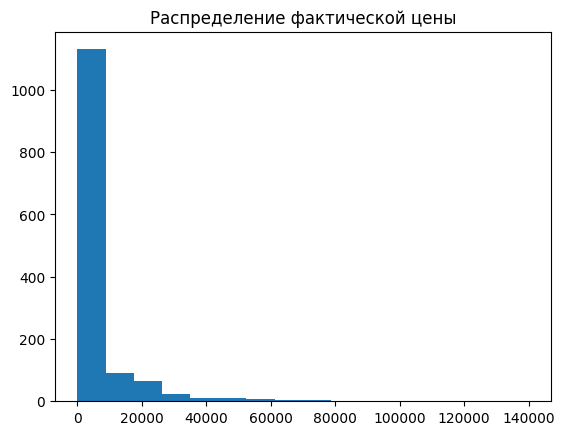

In [224]:
plt.hist(data['actual_price'],bins=16)
plt.title('Распределение фактической цены')
plt.show()

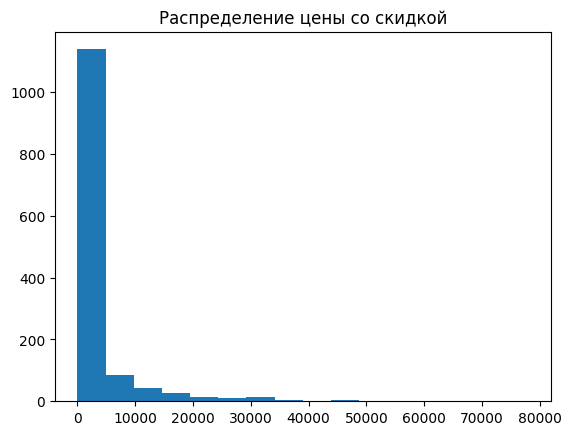

In [225]:
plt.hist(data['discounted_price'],bins=16)
plt.title('Распределение цены co скидкой')
plt.show()

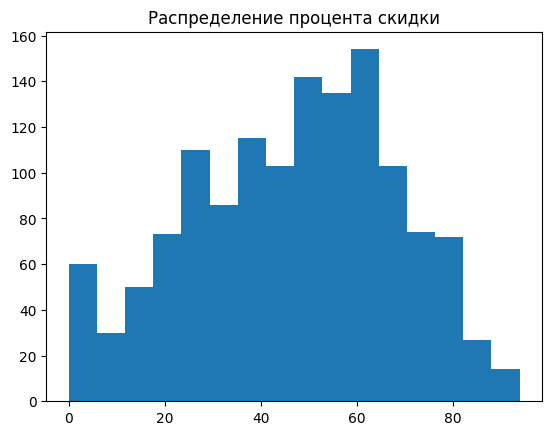

In [226]:
plt.hist(data['discount_percentage'],bins=16)
plt.title('Распределение процента скидки')
plt.show()

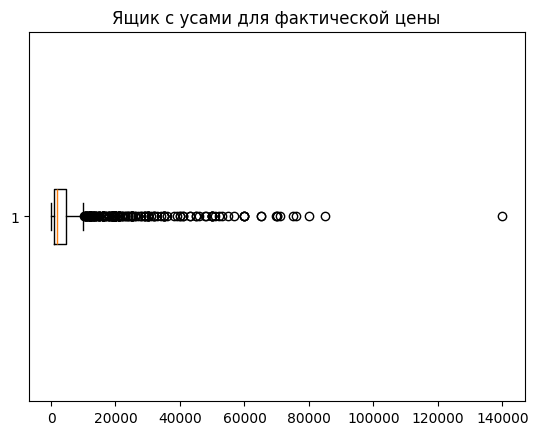

In [227]:
plt.boxplot(data['actual_price'],vert=False)
plt.title('Ящик с усами для фактической цены')
plt.show()

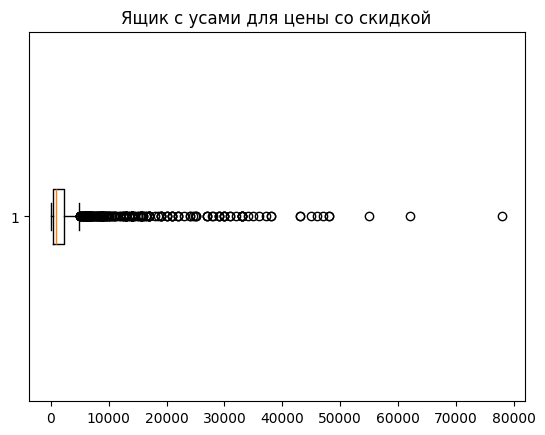

In [228]:
plt.boxplot(data['discounted_price'],vert=False)
plt.title('Ящик с усами для цены co скидкой')
plt.show()

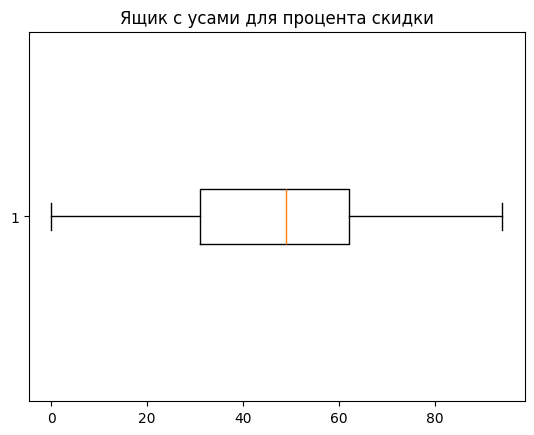

In [229]:
plt.boxplot(data['discount_percentage'],vert=False)
plt.title('Ящик с усами для процента скидки')
plt.show()

Вывод: фактическая цена и цена со скидкой имеют выраженную правостороннюю асимметрию: большинство товаров сосредоточено в нижнем ценовом диапазоне, при этом встречаются отдельные товары с очень высокой стоимостью. Медианные значения цен заметно ниже средних, а boxplot показывают большое количество потенциальных выбросов среди дорогих товаров. Распределение скидок значительно более равномерное и не демонстрирует выраженных выбросов.


## 3.3 Анализ рейтинга и популярности


In [230]:
data[['rating','rating_count']].describe()

,rating,rating_count
count,1348.000000,1348.000000
mean,4.091988,17656.847923
std,0.295139,42158.843602
min,2.000000,2.000000
25%,3.900000,1107.500000
50%,4.100000,4740.000000
75%,4.300000,16051.500000
max,5.000000,426973.000000


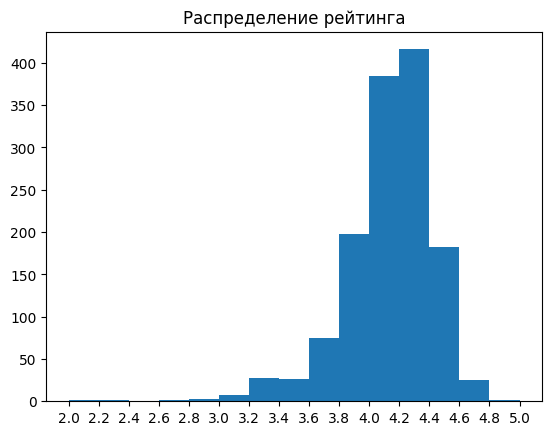

In [231]:
plt.hist(data['rating'],bins=15)
plt.title('Распределение рейтинга')
plt.xticks(np.arange(2,5.2,0.2))
plt.show()

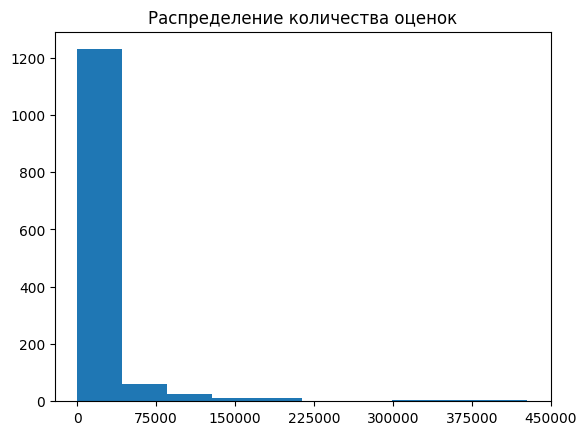

In [232]:
plt.hist(data['rating_count'],bins=10)
plt.title('Распределение количества оценок')
plt.xticks(np.arange(0,500000,75000))
plt.show()

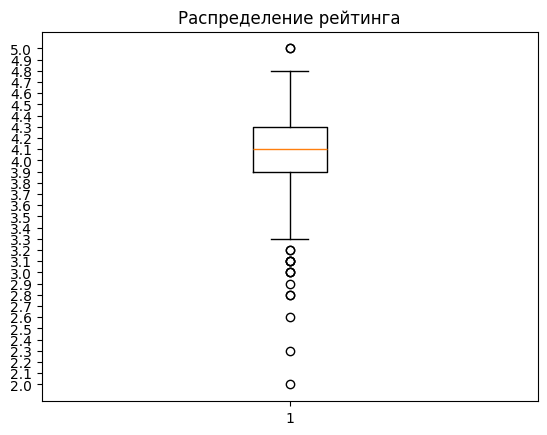

In [233]:
plt.boxplot(data['rating'])
plt.title('Распределение рейтинга')
plt.yticks(np.arange(2,5.1,0.1))
plt.show()

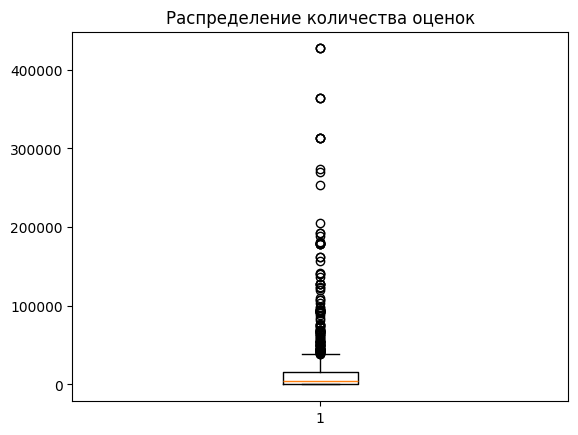

In [234]:
plt.boxplot(data['rating_count'])
plt.title('Распределение количества оценок')
plt.show()

Вывод: рейтинги товаров в основном сосредоточены вокруг высоких значений: средний рейтинг составляет около 4,09, медиана — 4,1, а половина товаров имеет рейтинг от 3,9 до 4,3. Количество оценок распределено значительно менее равномерно: медиана составляет 4 740 оценок, тогда как среднее — около 17,7 тыс., а максимальное значение достигает 426 973, что указывает на сильную правостороннюю асимметрию и наличие небольшой группы особенно популярных товаров.

### Вывод по разделу


Ассортимент датасета в основном представлен категориями **Electronics**, **Home&Kitchen** и **Computers&Accessories**, поэтому распределение товаров по категориям заметно несбалансировано.
Ценовые показатели имеют выраженную правостороннюю асимметрию: основная масса товаров относится к более низкому ценовому диапазону, тогда как отдельные дорогие товары существенно повышают средние значения. Рейтинги большинства товаров находятся на относительно высоком и близком уровне, в то время как популярность по `rating_count` различается значительно сильнее: небольшая часть товаров получает намного больше оценок, чем основная масса товаров.


# 4. Анализ взаимосвязей между показателями


## 4.1 Сравнение показателей между категориями


In [235]:
aggdata = data.groupby('category_main').agg(
    product_count=('product_id', 'count'),
    mean_rating=('rating', 'mean'),
    median_rating_count=('rating_count', 'median'),
    median_price=('discounted_price', 'median'),
    median_discount=('discount_percentage', 'median')
)
aggdata

,product_count,mean_rating,median_rating_count,median_price,median_discount
category_main,,,,,
Car&Motorbike,1,3.800000,1118.0,2339.0,42.0
Computers&Accessories,373,4.154692,7317.0,399.0,56.0
Electronics,490,4.077755,9129.5,1384.0,52.0
Health&PersonalCare,1,4.000000,3663.0,899.0,53.0
Home&Kitchen,447,4.040716,2311.0,1199.0,42.0
HomeImprovement,2,4.250000,4283.0,337.0,57.5
MusicalInstruments,2,3.900000,44441.0,638.0,46.0
OfficeProducts,31,4.309677,4426.0,178.0,5.0
Toys&Games,1,4.300000,15867.0,150.0,0.0


In [236]:
aggdata_filtered = aggdata[aggdata['product_count'] >= 30]

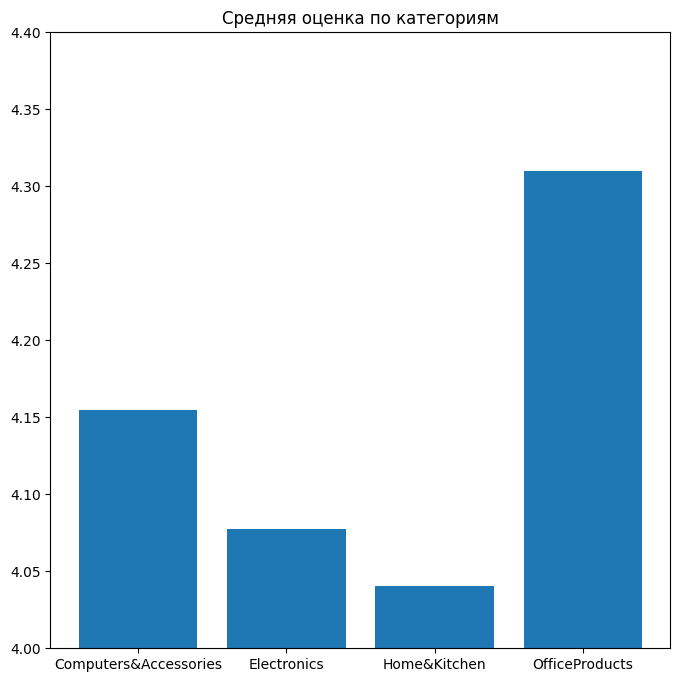

In [237]:
plt.figure(figsize=(8,8))
plt.title('Средняя оценка по категориям')
plt.bar(aggdata_filtered.index,aggdata_filtered['mean_rating'])
plt.ylim(4.0, 4.4)
plt.yticks(np.arange(4,4.4,0.05))
plt.show()

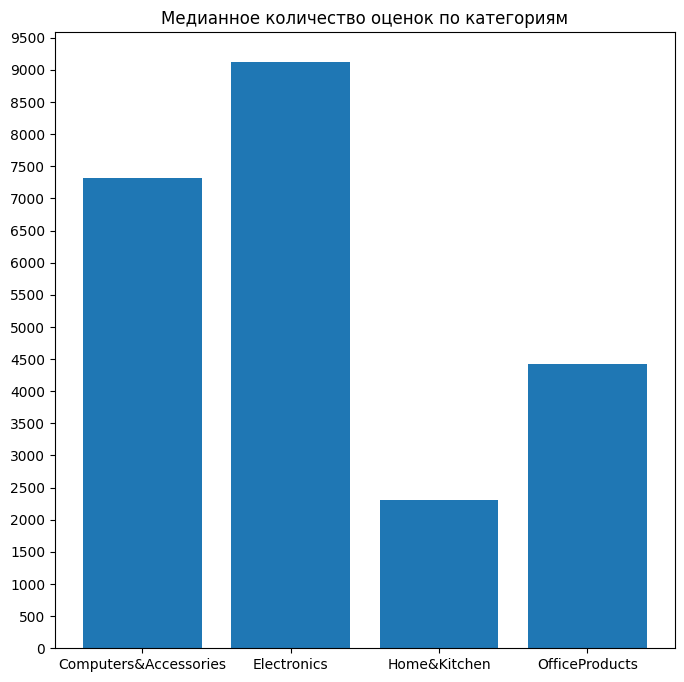

In [238]:
plt.figure(figsize=(8,8))
plt.title('Медианное количество оценок по категориям')
plt.bar(aggdata_filtered.index,aggdata_filtered['median_rating_count'])
plt.yticks(np.arange(0,10000,500))
plt.show()

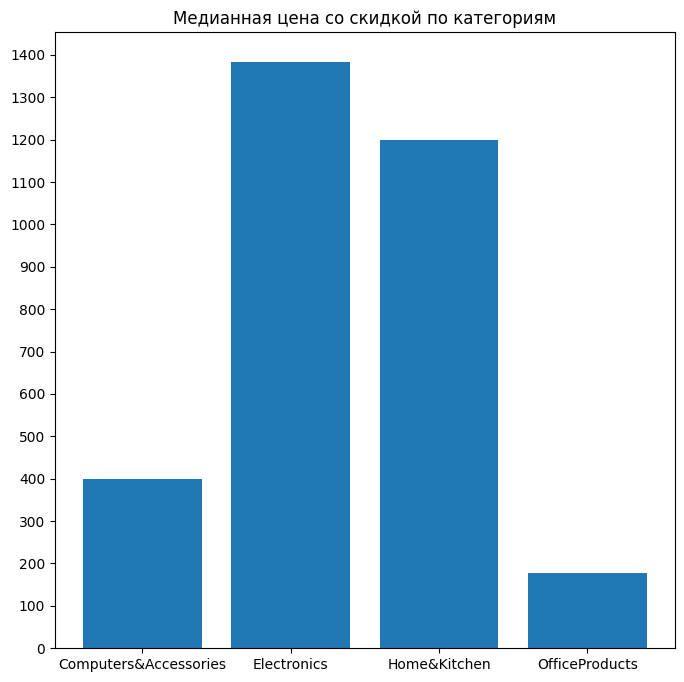

In [239]:
plt.figure(figsize=(8,8))
plt.title('Медианная цена со скидкой по категориям')
plt.bar(aggdata_filtered.index,aggdata_filtered['median_price'])
plt.yticks(np.arange(0,1500,100))
plt.show()

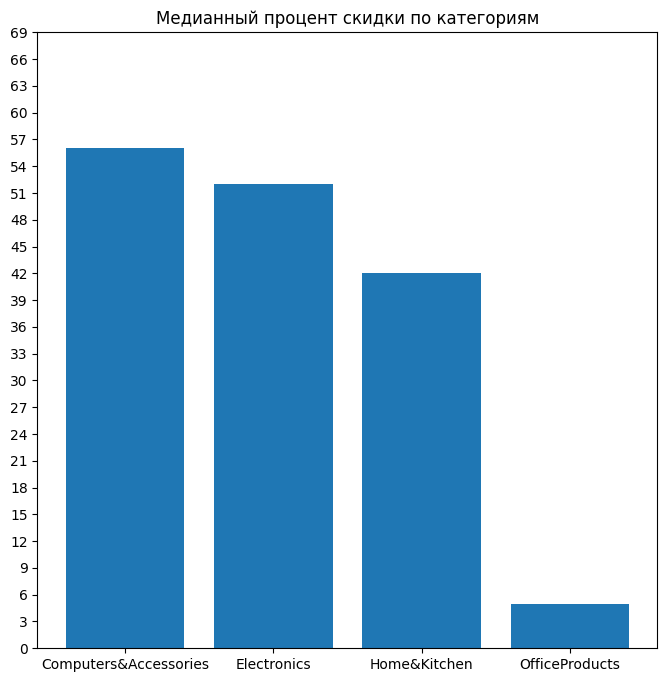

In [240]:
plt.figure(figsize=(8,8))
plt.title('Медианный процент скидки по категориям')
plt.bar(aggdata_filtered.index,aggdata_filtered['median_discount'])
plt.yticks(np.arange(0,70,3))
plt.show()

### Вывод по подразделу

Среди категорий с количеством товаров не менее 30 наиболее высокий средний рейтинг наблюдается у **OfficeProducts** — около **4,31**, однако эта категория представлена значительно меньшим числом товаров, чем три крупнейшие категории. Наибольшая медианная популярность по `rating_count` наблюдается у **Electronics** — около **9,1 тыс. оценок**, тогда как у **Home&Kitchen** она существенно ниже — около **2,3 тыс.**

Медианная цена со скидкой наиболее высокая у **Electronics**, а наиболее низкая — у **OfficeProducts**. По размеру скидок лидируют **Computers&Accessories** и **Electronics**, тогда как для **OfficeProducts** медианная скидка заметно ниже. Таким образом, категории различаются не только по уровню рейтинга, но и по популярности, цене и скидочной политике.

## 4.2 Связь скидки с рейтингом и популярностью


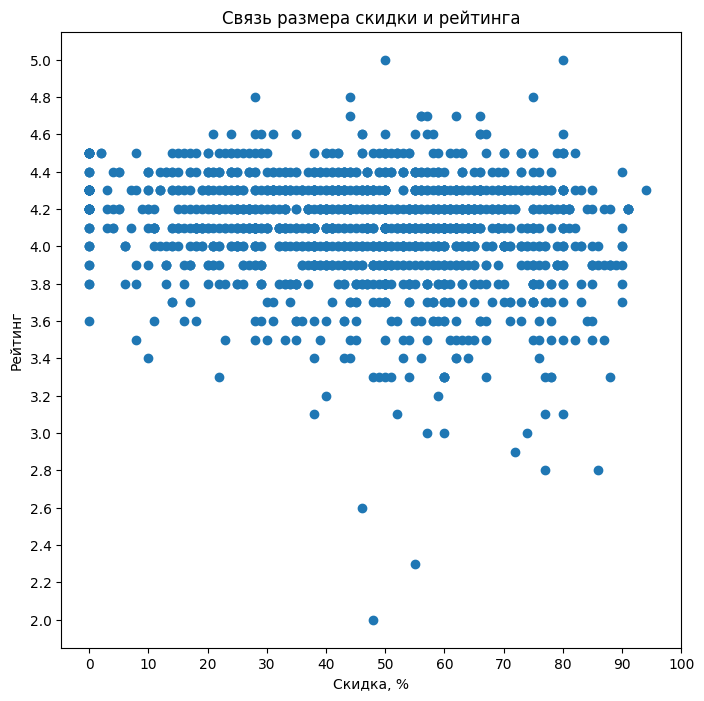

In [241]:
plt.figure(figsize=(8,8))
plt.title('Связь размера скидки и рейтинга')
plt.scatter(data['discount_percentage'],data['rating'])
plt.xlabel('Скидка, %')
plt.ylabel('Рейтинг')
plt.xticks(np.arange(0,110,10))
plt.yticks(np.arange(2,5.2,0.2))
plt.show()

In [242]:
data['discount_percentage'].corr(data['rating'])

np.float64(-0.16218996809748504)

In [243]:
data['discount_percentage'].corr(data['rating'],method='spearman')

np.float64(-0.14993583170926422)

Размер скидки имеет слабую отрицательную связь с рейтингом товара: коэффициент корреляции Пирсона составляет около **-0,16**, а Спирмена — около **-0,15**. Это указывает на небольшую тенденцию к снижению рейтинга при увеличении скидки, однако связь является слабой и не позволяет говорить о существенном влиянии скидки на пользовательскую удовлетворённость.

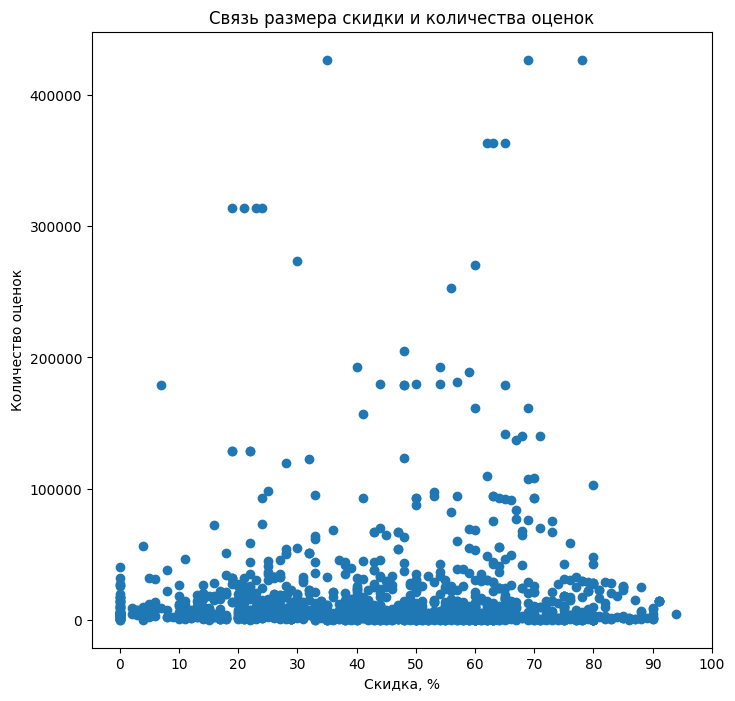

In [244]:
plt.figure(figsize=(8,8))
plt.title('Связь размера скидки и количества оценок')
plt.scatter(data['discount_percentage'],data['rating_count'])
plt.xlabel('Скидка, %')
plt.ylabel('Количество оценок')
plt.xticks(np.arange(0,110,10))
plt.show()

In [245]:
data['discount_percentage'].corr(data['rating_count'])

np.float64(0.0034431919011727176)

In [246]:
data['discount_percentage'].corr(data['rating_count'],method='spearman')

np.float64(-0.13222692394121946)

Размер скидки практически не связан с популярностью товара по `rating_count`. Коэффициент корреляции Пирсона составляет около **0,00**, что указывает на отсутствие линейной связи, а коэффициент Спирмена — около **-0,13**, что соответствует очень слабой отрицательной монотонной связи. Таким образом, товары с большими скидками не демонстрируют заметно более высокую популярность.

### Вывод по подразделу

Размер скидки имеет лишь слабую связь с анализируемыми показателями. Для рейтинга наблюдается слабая отрицательная корреляция, а для количества оценок линейная связь практически отсутствует. Поэтому на основании этих данных нельзя считать размер скидки существенным фактором пользовательской удовлетворённости или популярности товара.

## 4.3 Связь цены с рейтингом и популярностью


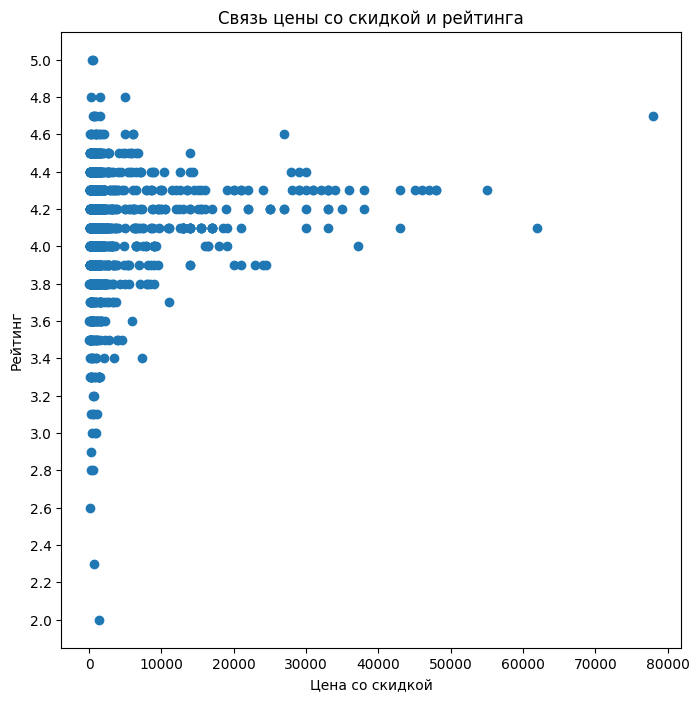

In [247]:
plt.figure(figsize=(8,8))
plt.title('Связь цены со скидкой и рейтинга')
plt.scatter(data['discounted_price'],data['rating'])
plt.xlabel('Цена со скидкой')
plt.ylabel('Рейтинг')
plt.yticks(np.arange(2,5.2,0.2))
plt.show()

In [248]:
data['discounted_price'].corr(data['rating'])

np.float64(0.12724746380370805)

In [249]:
data['discounted_price'].corr(data['rating'],method='spearman')

np.float64(0.07685623944689622)

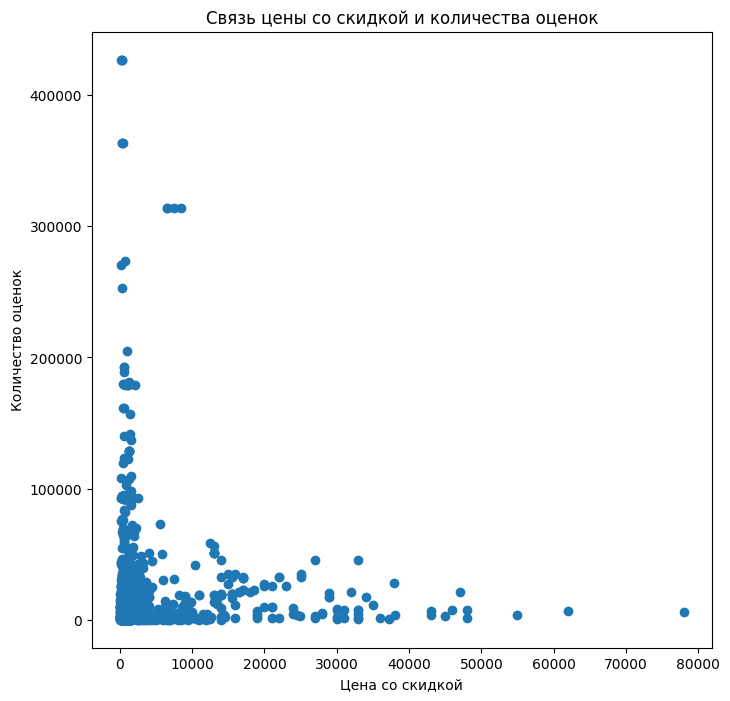

In [250]:
plt.figure(figsize=(8,8))
plt.title('Связь цены со скидкой и количества оценок')
plt.scatter(data['discounted_price'],data['rating_count'])
plt.xlabel('Цена со скидкой')
plt.ylabel('Количество оценок')
plt.show()

In [251]:
data['discounted_price'].corr(data['rating_count'])

np.float64(-0.024105887969107457)

In [252]:
data['discounted_price'].corr(data['rating_count'],method='spearman')

np.float64(0.14666019823762583)

### Вывод по подразделу

Связь цены со скидкой с рейтингом и популярностью товаров является слабой. Для рейтинга коэффициент Спирмена составляет около **0,08**, а для количества оценок — около **0,15**. Это означает, что более высокая или низкая цена не связана с существенными изменениями пользовательского рейтинга или популярности товара.

### Вывод по разделу



Категории товаров различаются по рейтингу, популярности, цене и размеру скидки, однако анализ отдельных числовых характеристик не выявил сильных взаимосвязей.

Размер скидки имеет лишь слабую отрицательную связь с рейтингом и популярностью, а цена показывает только очень слабую положительную связь с этими показателями. Таким образом, ни цена, ни размер скидки сами по себе не позволяют хорошо объяснить различия в пользовательской удовлетворённости и популярности товаров.

# 5. Сегментация товаров и поиск проблемных продуктов


## 5.1 Определение критериев популярности и удовлетворённости


In [253]:
medians=pd.Series([data['rating'].median(),data['rating_count'].median()],index=['медиана rating','медиана rating_count'])
medians

,0
медиана rating,4.1
медиана rating_count,4740.0


### Вывод по подразделу

В качестве границ для сегментации использованы медианные значения показателей: **4,1** для рейтинга и **4 740** для количества оценок. Такой подход позволяет разделить товары относительно типичного уровня пользовательской удовлетворённости и популярности и снижает влияние экстремальных значений `rating_count`.

## 5.2 Сегментация товаров


In [254]:
conditions = [
    (data['rating'] >= medians.loc['медиана rating']) &
    (data['rating_count'] >= medians.loc['медиана rating_count']),

    (data['rating'] >= medians.loc['медиана rating']) &
    (data['rating_count'] < medians.loc['медиана rating_count']),

    (data['rating'] < medians.loc['медиана rating']) &
    (data['rating_count'] >= medians.loc['медиана rating_count']),

    (data['rating'] < medians.loc['медиана rating']) &
    (data['rating_count'] < medians.loc['медиана rating_count'])
]

segments = [
    'Высокий рейтинг / Высокая популярность',
    'Высокий рейтинг / Низкая популярность',
    'Низкий рейтинг / Высокая популярность',
    'Низкий рейтинг / Низкая популярность'
]

data['segment'] = np.select(conditions, segments,default='Не определено')

In [255]:
segment_counts= data['segment'].value_counts()

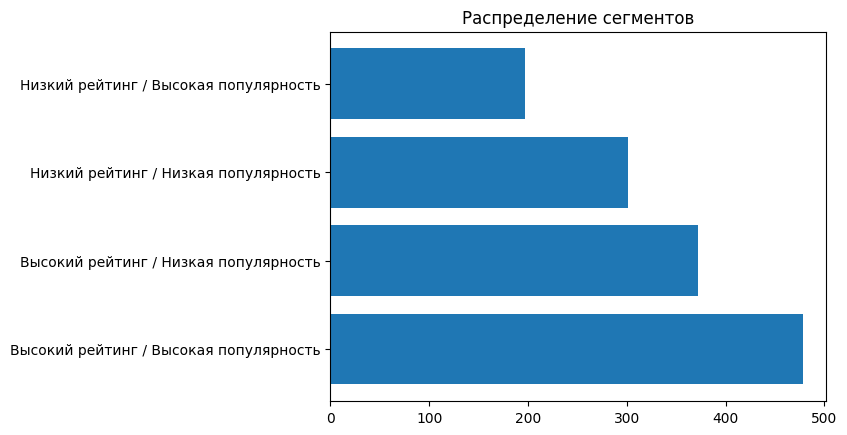

In [256]:
plt.title('Распределение сегментов')
plt.barh(segment_counts.index,segment_counts)
plt.show()

### Вывод по подразделу

Наибольшую группу составляют товары с **высоким рейтингом и высокой популярностью** — 478 товаров. При этом 197 товаров относятся к сегменту **низкий рейтинг / высокая популярность**: они получают большое количество оценок, но имеют рейтинг ниже медианного уровня. Именно эта группа представляет наибольший интерес для дальнейшего анализа потенциально проблемных товаров.

## 5.3 Выявление потенциально проблемных товаров


In [257]:
problem_products=data[data['segment']=='Низкий рейтинг / Высокая популярность']
problem_products=problem_products[['product_name',
                 'category_main',
                 'discounted_price',
                 'discount_percentage',
                 'rating',
                 'rating_count']].sort_values(by='rating_count',ascending=False)
problem_products.head(10)

,product_name,category_main,discounted_price,discount_percentage,rating,rating_count
589,boAt Airdopes 121v2 in-Ear True Wireless Earbu...,Electronics,1299.0,57,3.8,180998.0
583,boAt Airdopes 141 Bluetooth Truly Wireless in ...,Electronics,1499.0,67,3.9,136954.0
439,"Nokia 105 Plus Single SIM, Keypad Mobile Phone...",Electronics,1324.0,22,4.0,128311.0
412,"Nokia 105 Single SIM, Keypad Mobile Phone with...",Electronics,1299.0,19,4.0,128311.0
343,"Nokia 105 Single SIM, Keypad Mobile Phone with...",Electronics,1299.0,19,4.0,128311.0
447,"Nokia 105 Plus Single SIM, Keypad Mobile Phone...",Electronics,1324.0,22,4.0,128311.0
1020,Pigeon by Stovekraft Amaze Plus Electric Kettl...,Home&Kitchen,649.0,48,3.9,123365.0
654,Boult Audio Probass Curve Bluetooth Wireless i...,Electronics,899.0,80,3.8,103052.0
599,"JBL C50HI, Wired in Ear Headphones with Mic, O...",Electronics,499.0,50,3.9,92995.0
743,Noise ColorFit Pro 2 Full Touch Control Smart ...,Electronics,1499.0,70,4.0,92588.0


### Вывод по подразделу

В сегмент потенциально проблемных товаров вошли продукты с высокой популярностью, но рейтингом ниже медианного уровня. Среди наиболее популярных таких товаров преобладает категория **Electronics**; отдельные товары имеют более **100 тыс. оценок** при рейтинге около **3,8–4,0**.

Эти товары требуют приоритетного внимания, поскольку относительно низкий рейтинг сочетается с высокой пользовательской активностью. Для принятия конкретных решений необходимо дополнительно изучить содержание отзывов и причины более низких оценок.

### Вывод по разделу


Сегментация товаров по медианным значениям рейтинга и количества оценок позволила выделить четыре группы по сочетанию пользовательской удовлетворённости и популярности.

Наиболее многочисленным оказался сегмент товаров с высоким рейтингом и высокой популярностью — **478 товаров**. При этом **197 товаров** относятся к потенциально проблемной группе: они имеют высокую популярность, но рейтинг ниже медианного уровня **4,1**.

Такие товары представляют наибольший интерес для дальнейшего исследования, поскольку большое количество оценок указывает на значительную пользовательскую активность, а относительно низкий рейтинг может свидетельствовать о проблемах с качеством товара или ожиданиями покупателей.


# 6. Итоговые выводы и рекомендации


## 6.1 Ключевые результаты анализа


В ходе анализа было установлено, что ассортимент датасета в основном сосредоточен в трёх категориях: **Electronics**, **Home&Kitchen** и **Computers&Accessories**. При этом распределение товаров по категориям является заметно несбалансированным.

Цены товаров имеют выраженную правостороннюю асимметрию: большинство товаров относится к более низкому ценовому диапазону, тогда как отдельные дорогие товары существенно повышают средние значения. Рейтинги, напротив, сосредоточены в относительно узком диапазоне вокруг **4,1**, а количество оценок различается между товарами значительно сильнее.

Анализ взаимосвязей показал, что ни размер скидки, ни цена не имеют сильной связи с рейтингом или популярностью товара. Наблюдаемые коэффициенты корреляции являются слабыми, поэтому эти характеристики сами по себе не позволяют хорошо объяснить различия в пользовательской удовлетворённости и популярности.

Сегментация по рейтингу и количеству оценок позволила выделить четыре группы товаров. Наиболее многочисленным оказался сегмент **«Высокий рейтинг / Высокая популярность»** — 478 товаров. При этом **197 товаров** попали в потенциально проблемный сегмент **«Низкий рейтинг / Высокая популярность»**, что делает их приоритетной группой для дальнейшего исследования.


## 6.2 Бизнес-рекомендации


В первую очередь рекомендуется обратить внимание на товары из сегмента **«Низкий рейтинг / Высокая популярность»**. Такие товары имеют значительную пользовательскую активность, поэтому даже небольшое улучшение качества продукта или клиентского опыта потенциально может затронуть большое количество покупателей.

Для этой группы стоит провести дополнительный анализ текстов отзывов, чтобы определить основные причины более низких оценок: качество товара, несоответствие ожиданиям, проблемы с доставкой, комплектацией или описанием продукта.

Товары из сегмента **«Высокий рейтинг / Низкая популярность»** можно рассматривать как потенциально перспективные. Для них имеет смысл дополнительно проверить факторы, которые могут ограничивать популярность: видимость товара, цена, размер скидки, позиционирование или представленность в категории.

Поскольку анализ не выявил сильной связи цены и размера скидки с рейтингом и популярностью, не следует рассматривать снижение цены или увеличение скидки как универсальный способ повышения эффективности товара. Решения по ассортименту и продвижению лучше принимать с учётом сочетания нескольких показателей и особенностей конкретной категории.


## 6.3 Ограничения анализа


Датасет представляет собой статический срез и не содержит временных данных, поэтому невозможно оценить динамику рейтингов, популярности и цен товаров во времени.

В данных отсутствуют показатели продаж, выручки, просмотров и конверсии. По этой причине `rating_count` используется только как приближённый показатель популярности товара и не может напрямую интерпретироваться как объём продаж.

Полученные корреляции отражают только статистическую связь между показателями и не позволяют делать выводы о причинно-следственном влиянии цены или скидки на рейтинг и популярность.

Кроме того, категории представлены в датасете неравномерно, поэтому результаты по малочисленным категориям следует интерпретировать с осторожностью.


## Итоговый вывод


Проведённый анализ показал, что эффективность товаров Amazon нельзя объяснить только ценой или размером скидки: их связь с рейтингом и популярностью оказалась слабой. Более полезным оказался совместный анализ пользовательской удовлетворённости и популярности, который позволил выделить как сильные товары, так и потенциально проблемную группу с высокой популярностью и относительно низким рейтингом.

Полученные результаты могут использоваться как основа для приоритизации дальнейшего анализа ассортимента. В первую очередь имеет смысл исследовать причины низких оценок у популярных товаров и отдельно изучить перспективные товары с высоким рейтингом, но сравнительно низкой популярностью.
